# Case Study 2 — Report 7 (Test 5C)

**CORAL λ=0.1 verified across 3 subject splits (robustness check)**

Student: Sanjeev Veeramani (Matr. 100004303)
Supervisor: Prof. Dr. Binh Vu

---

**Objective.** Verify that Test 5B's CORAL λ=0.1 results (binary per_window 68.59%) hold across different subject splits — not just an artifact of val subjects 1-3.

**Test 5B was single-split.** Test 4B showed splits vary by ~2.5-2.7 pp — so a single number could be misleading.

**Setup:**
- Model: CNN-LSTM+Attention + MMD + CORAL (λ_coral = 0.1)
- 3 subject splits (same as Test 4B):
  - Split A: val [1, 2, 3], test [4-15]
  - Split B: val [6, 7, 8], test [1-5, 9-15]
  - Split C: val [13, 14, 15], test [1-12]
- Grid: 3 splits × 4 configs (2 mappings × 2 protocols) = 12 runs

**Zero-shot compliance:** ❌ NO — this is unsupervised DA (uses SEED features during training).

**Expected runtime:** ~4 hours on L4 GPU.

**Purpose:** Get honest mean ± std for CORAL UDA, compare to Test 4B (zero-shot) mean ± std.

## 1. Setup

In [1]:
from google.colab import drive
drive.mount('/content/drive')

import os
PROJECT_ROOT = '/content/drive/MyDrive/case_study_2'
assert os.path.isdir(PROJECT_ROOT)

Mounted at /content/drive


In [2]:
import torch, numpy as np, pandas as pd, time, gc
from pathlib import Path
import torch.nn as nn
import torch.nn.functional as F
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
                             f1_score, precision_score, recall_score)

SEED = 42
np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    torch.backends.cudnn.benchmark = True
print('Device:', torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU')

Device: NVIDIA L4


## 2. Configuration

In [3]:
CONFIG = {
    'deap_de_perwindow':  'processed/X_deap_DE_zscored.npy',
    'deap_subj_ids':      'processed/deap_subject_ids.npy',
    'deap_val_bin':       'processed/y_deap_valence.npy',
    'deap_val_3c':        'processed/y_deap_3class.npy',

    'seed_de_perwindow':  'processed/X_seed_DE_zscored.npy',
    'seed_subj_ids':      'processed/seed_subject_ids.npy',
    'seed_labels':        'processed/y_seed.npy',
    'seed_de_pertrial':      'processed/X_seed_DE_pertrial.npy',
    'seed_subj_ids_pertrial':'processed/subj_seed_pertrial.npy',
    'seed_labels_pertrial':  'processed/y_seed_pertrial.npy',

    'deap_n_subjects':    32,
    'deap_n_trials':      40,

    'results_dir':  'results/report7_test5c_coral_multisplit',

    'lr':            1e-3,
    'weight_decay':  1e-4,
    'mmd_lambda':    0.1,
    'coral_lambda':  0.1,   # Best λ found in Test 5B

    'splits': {
        'A': {'val': [1, 2, 3],     'test': list(range(4, 16))},
        'B': {'val': [6, 7, 8],     'test': [1,2,3,4,5,9,10,11,12,13,14,15]},
        'C': {'val': [13, 14, 15],  'test': list(range(1, 13))},
    },
}

RESULTS_DIR = Path(PROJECT_ROOT) / CONFIG['results_dir']
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f'CORAL λ: {CONFIG["coral_lambda"]}')
for k, v in CONFIG['splits'].items():
    print(f'Split {k}: val {v["val"]}')

CORAL λ: 0.1
Split A: val [1, 2, 3]
Split B: val [6, 7, 8]
Split C: val [13, 14, 15]


## 3. Load data

In [4]:
root = Path(PROJECT_ROOT)

X_deap_pw  = np.load(root / CONFIG['deap_de_perwindow']).astype(np.float32)
subj_deap  = np.load(root / CONFIG['deap_subj_ids']).astype(np.int64)
y_deap_bin = np.load(root / CONFIG['deap_val_bin']).astype(np.int64)
y_deap_3c  = np.load(root / CONFIG['deap_val_3c']).astype(np.int64)

n_sub_d, n_tr_d = CONFIG['deap_n_subjects'], CONFIG['deap_n_trials']
n_win_d = X_deap_pw.shape[0] // (n_sub_d * n_tr_d)
X_deap_pt = X_deap_pw.reshape(n_sub_d, n_tr_d, n_win_d, -1).mean(axis=2).reshape(-1, X_deap_pw.shape[-1])
y_deap_bin_pt = y_deap_bin.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
y_deap_3c_pt  = y_deap_3c.reshape(n_sub_d, n_tr_d, n_win_d)[:, :, 0].reshape(-1)
subj_deap_pt = np.repeat(np.arange(1, n_sub_d + 1), n_tr_d).astype(np.int64)

X_seed_pw    = np.load(root / CONFIG['seed_de_perwindow']).astype(np.float32)
subj_seed_pw = np.load(root / CONFIG['seed_subj_ids']).astype(np.int64)
y_seed_pw    = np.load(root / CONFIG['seed_labels']).astype(np.int64)
X_seed_pt    = np.load(root / CONFIG['seed_de_pertrial']).astype(np.float32)
subj_seed_pt = np.load(root / CONFIG['seed_subj_ids_pertrial']).astype(np.int64)
y_seed_pt    = np.load(root / CONFIG['seed_labels_pertrial']).astype(np.int64)

print(f'DEAP per-window: {X_deap_pw.shape}, per-trial: {X_deap_pt.shape}')
print(f'SEED per-window: {X_seed_pw.shape}, per-trial: {X_seed_pt.shape}')

DEAP per-window: (152320, 160), per-trial: (1280, 160)
SEED per-window: (304785, 160), per-trial: (675, 160)


## 4. Split helper

In [5]:
def build_split_data(split_name):
    val_subjs  = set(CONFIG['splits'][split_name]['val'])
    test_subjs = set(CONFIG['splits'][split_name]['test'])

    def split(X, y, subj):
        vm = np.isin(subj, list(val_subjs))
        tm = np.isin(subj, list(test_subjs))
        return {'val': (X[vm], y[vm], subj[vm]), 'test': (X[tm], y[tm], subj[tm])}

    seed_splits = {
        'per_trial':  split(X_seed_pt, y_seed_pt, subj_seed_pt),
        'per_window': split(X_seed_pw, y_seed_pw, subj_seed_pw),
    }

    def map_binary(X, y, s):
        m = (y == 0) | (y == 2)
        return X[m], (y[m] == 2).astype(np.int64), s[m]
    def map_3class(X, y, s):
        return X, y.astype(np.int64), s

    data = {}
    for protocol in ['per_trial', 'per_window']:
        for role in ['val', 'test']:
            X, y, s = seed_splits[protocol][role]
            for mapping, fn in [('binary', map_binary), ('3class', map_3class)]:
                Xm, ym, sm = fn(X, y, s)
                data[(mapping, protocol, role)] = (Xm, ym, sm)
    return data

## 5. Model + CORAL loss

In [6]:
EMBED_DIM = 128

class AttentionPool(nn.Module):
    def __init__(self, in_dim, hidden=64):
        super().__init__()
        self.score = nn.Sequential(nn.Linear(in_dim, hidden), nn.Tanh(),
                                   nn.Linear(hidden, 1))
    def forward(self, x):
        w = self.score(x).squeeze(-1)
        w = torch.softmax(w, dim=1).unsqueeze(-1)
        return (x * w).sum(dim=1)

class CNNLSTMAttentionExtractor(nn.Module):
    def __init__(self, n_bands=5, embed=EMBED_DIM):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv1d(n_bands, 32, kernel_size=3, padding=1),
            nn.BatchNorm1d(32), nn.ReLU(),
            nn.Conv1d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm1d(64), nn.ReLU(),
        )
        self.lstm = nn.LSTM(64, 128, num_layers=2, batch_first=True,
                            dropout=0.3, bidirectional=False)
        self.attn = AttentionPool(128, hidden=64)
        self.fc = nn.Sequential(nn.Linear(128, embed), nn.ReLU(), nn.Dropout(0.3))
    def forward(self, x):
        b = x.size(0)
        x = x.view(b, 32, 5).transpose(1, 2)
        x = self.conv(x).transpose(1, 2)
        h, _ = self.lstm(x)
        return self.fc(self.attn(h))

class EmotionModel(nn.Module):
    def __init__(self, n_classes):
        super().__init__()
        self.extractor = CNNLSTMAttentionExtractor()
        self.head = nn.Sequential(
            nn.Linear(EMBED_DIM, 64), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(64, n_classes))
    def forward(self, x, return_features=False):
        feat = self.extractor(x)
        logits = self.head(feat)
        return (logits, feat) if return_features else logits

def linear_mmd_by_subject(features, subject_ids):
    unique = torch.unique(subject_ids)
    if len(unique) < 2:
        return torch.tensor(0.0, device=features.device)
    means = [features[subject_ids == s].mean(dim=0)
             for s in unique if (subject_ids == s).sum() > 0]
    means = torch.stack(means)
    diffs = means.unsqueeze(0) - means.unsqueeze(1)
    sq = (diffs * diffs).sum(dim=-1)
    n = len(unique)
    return sq.sum() / max(n * (n - 1), 1)

def coral_loss(source_feat, target_feat):
    d = source_feat.size(1)
    src_c = source_feat - source_feat.mean(0, keepdim=True)
    tgt_c = target_feat - target_feat.mean(0, keepdim=True)
    ns = max(source_feat.size(0), 2)
    nt = max(target_feat.size(0), 2)
    cov_s = (src_c.t() @ src_c) / (ns - 1)
    cov_t = (tgt_c.t() @ tgt_c) / (nt - 1)
    return ((cov_s - cov_t) ** 2).sum() / (4 * d * d)

## 6. Training with CORAL λ=0.1 + val-based early stopping

In [7]:
def train_with_coral(X_train_np, y_train_np, subj_train_np,
                     X_seed_unlabeled_np, X_val_np, y_val_np,
                     X_test_np, y_test_np,
                     n_classes, epochs, batch_size, lr, wd,
                     mmd_lambda, coral_lambda):
    X_tr = torch.from_numpy(X_train_np).to(DEVICE)
    y_tr = torch.from_numpy(y_train_np).long().to(DEVICE)
    s_tr = torch.from_numpy(subj_train_np).long().to(DEVICE)
    X_seed_pool = torch.from_numpy(X_seed_unlabeled_np).to(DEVICE)
    X_val = torch.from_numpy(X_val_np).to(DEVICE)
    X_te  = torch.from_numpy(X_test_np).to(DEVICE)

    unique_s = torch.unique(s_tr)
    remap = torch.zeros(int(unique_s.max()) + 1, dtype=torch.long, device=DEVICE)
    remap[unique_s] = torch.arange(unique_s.size(0), device=DEVICE)
    s_tr_remap = remap[s_tr]

    model = EmotionModel(n_classes).to(DEVICE)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=wd)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=epochs)

    counts = np.bincount(y_train_np, minlength=n_classes)
    w = 1.0 / (counts + 1e-10); w = w / w.sum() * n_classes
    loss_fn = nn.CrossEntropyLoss(weight=torch.tensor(w, dtype=torch.float32, device=DEVICE))

    best_val_bal, best_state, best_epoch = -1.0, None, 0
    n = X_tr.size(0)
    n_seed = X_seed_pool.size(0)

    for ep in range(epochs):
        model.train()
        perm = torch.randperm(n, device=DEVICE)
        for start in range(0, n, batch_size):
            idx = perm[start:start+batch_size]
            if idx.size(0) < 2: continue
            xb_src, yb, sb = X_tr[idx], y_tr[idx], s_tr_remap[idx]
            seed_idx = torch.randint(0, n_seed, (idx.size(0),), device=DEVICE)
            xb_tgt = X_seed_pool[seed_idx]

            opt.zero_grad()
            src_logits, src_feat = model(xb_src, return_features=True)
            _,           tgt_feat = model(xb_tgt, return_features=True)

            ce   = loss_fn(src_logits, yb)
            mmd  = linear_mmd_by_subject(src_feat, sb)
            coral = coral_loss(src_feat, tgt_feat)
            loss = ce + mmd_lambda * mmd + coral_lambda * coral

            loss.backward(); opt.step()
        sched.step()

        model.eval()
        with torch.no_grad():
            preds_val = []
            for i in range(0, X_val.size(0), batch_size*2):
                preds_val.append(model(X_val[i:i+batch_size*2]).argmax(dim=1))
            y_pred_val = torch.cat(preds_val).cpu().numpy()
        val_bal = balanced_accuracy_score(y_val_np, y_pred_val)

        if val_bal > best_val_bal:
            best_val_bal = val_bal
            best_epoch = ep
            best_state = {k: v.detach().clone() for k, v in model.state_dict().items()}

    model.load_state_dict(best_state)
    model.eval()
    with torch.no_grad():
        preds_test = []
        for i in range(0, X_te.size(0), batch_size*2):
            preds_test.append(model(X_te[i:i+batch_size*2]).argmax(dim=1))
        y_pred_test = torch.cat(preds_test).cpu().numpy()

    test_bal = balanced_accuracy_score(y_test_np, y_pred_test)
    return y_pred_test, test_bal, best_val_bal, best_epoch

## 7. Main loop — 3 splits × 4 configs = 12 runs

In [8]:
def get_deap_train_set(mapping, protocol):
    if protocol == 'per_trial':
        X = X_deap_pt; subj = subj_deap_pt
        y = y_deap_bin_pt if mapping == 'binary' else y_deap_3c_pt
    else:
        X = X_deap_pw; subj = subj_deap
        y = y_deap_bin if mapping == 'binary' else y_deap_3c
    return X.astype(np.float32), y.astype(np.int64), subj.astype(np.int64)

def get_seed_pool(protocol):
    return X_seed_pt.astype(np.float32) if protocol == 'per_trial' else X_seed_pw.astype(np.float32)

ALL_RESULTS = {}
for split_name in ['A', 'B', 'C']:
    print(f'\n{"#"*60}\n# SPLIT {split_name}   val: {CONFIG["splits"][split_name]["val"]}\n{"#"*60}')
    DATA = build_split_data(split_name)

    for mapping in ['binary', '3class']:
        for protocol in ['per_trial', 'per_window']:
            key = (split_name, mapping, protocol)
            print(f'\n[Split {split_name}] {mapping} × {protocol}')

            X_train, y_train, subj_train = get_deap_train_set(mapping, protocol)
            X_seed_pool = get_seed_pool(protocol)
            X_val, y_val, _   = DATA[(mapping, protocol, 'val')]
            X_test, y_test, _ = DATA[(mapping, protocol, 'test')]

            n_classes = 3 if mapping == '3class' else 2
            batch = 512 if protocol == 'per_window' else 128
            epochs = 20 if protocol == 'per_window' else 40

            t0 = time.time()
            y_pred, test_bal, val_bal, best_ep = train_with_coral(
                X_train, y_train, subj_train, X_seed_pool,
                X_val, y_val, X_test, y_test,
                n_classes, epochs, batch,
                CONFIG['lr'], CONFIG['weight_decay'],
                CONFIG['mmd_lambda'], CONFIG['coral_lambda'])
            elapsed = time.time() - t0

            print(f'  epoch {best_ep+1} | val {100*val_bal:.2f}% | test {100*test_bal:.2f}% | time {elapsed:.1f}s')

            ALL_RESULTS[key] = {
                'y_true': y_test, 'y_pred': y_pred,
                'test_bal': test_bal, 'val_bal': val_bal, 'best_epoch': best_ep,
            }

            del X_train, y_train, subj_train, X_seed_pool
            gc.collect()
            if torch.cuda.is_available(): torch.cuda.empty_cache()


############################################################
# SPLIT A   val: [1, 2, 3]
############################################################

[Split A] binary × per_trial
  epoch 13 | val 57.78% | test 56.67% | time 24.5s

[Split A] binary × per_window
  epoch 5 | val 58.80% | test 63.79% | time 168.2s

[Split A] 3class × per_trial
  epoch 9 | val 38.52% | test 40.74% | time 12.9s

[Split A] 3class × per_window
  epoch 7 | val 39.86% | test 42.14% | time 168.2s

############################################################
# SPLIT B   val: [6, 7, 8]
############################################################

[Split B] binary × per_trial
  epoch 4 | val 73.33% | test 63.89% | time 9.5s

[Split B] binary × per_window
  epoch 1 | val 73.28% | test 64.56% | time 162.7s

[Split B] 3class × per_trial
  epoch 14 | val 49.63% | test 42.96% | time 9.5s

[Split B] 3class × per_window
  epoch 1 | val 52.63% | test 45.05% | time 164.9s

###################################################

## 8. Aggregate + compare Test 4B (SEED-validation) vs CORAL (Test 5C)

In [9]:
# Per-run
rows_per = []
for (split, mapping, protocol), r in ALL_RESULTS.items():
    rows_per.append({
        'split': split, 'mapping': mapping, 'protocol': protocol,
        'val_bal':  100 * r['val_bal'],
        'test_bal': 100 * r['test_bal'],
        'best_epoch': r['best_epoch'] + 1,
    })
DF_PER = pd.DataFrame(rows_per)
DF_PER.to_csv(RESULTS_DIR / 'per_split_test5c.csv', index=False)
print('=== Per-split results ===')
print(DF_PER.to_string(index=False))

# Aggregated
rows_agg = []
for mapping in ['binary', '3class']:
    for protocol in ['per_trial', 'per_window']:
        sub = DF_PER[(DF_PER['mapping']==mapping) & (DF_PER['protocol']==protocol)]
        rows_agg.append({
            'mapping': mapping, 'protocol': protocol,
            'test_bal_mean_CORAL': sub['test_bal'].mean(),
            'test_bal_std_CORAL':  sub['test_bal'].std(),
            'test_bal_min_CORAL':  sub['test_bal'].min(),
            'test_bal_max_CORAL':  sub['test_bal'].max(),
        })
DF_AGG = pd.DataFrame(rows_agg)
DF_AGG.to_csv(RESULTS_DIR / 'aggregated_test5c.csv', index=False)
print('\n=== Aggregated across 3 splits ===')
print(DF_AGG.to_string(index=False))

# Compare to Test 4B (zero-shot mean)
TEST4B_MEAN = {
    ('binary',  'per_trial'):  (62.69, 2.58),
    ('binary',  'per_window'): (64.90, 2.72),
    ('3class',  'per_trial'):  (43.33, 2.69),
    ('3class',  'per_window'): (43.48, 0.26),
}

compare = []
for mapping in ['binary', '3class']:
    for protocol in ['per_trial', 'per_window']:
        z_mean, z_std = TEST4B_MEAN[(mapping, protocol)]
        sub = DF_PER[(DF_PER['mapping']==mapping) & (DF_PER['protocol']==protocol)]
        c_mean = sub['test_bal'].mean()
        c_std  = sub['test_bal'].std()
        compare.append({
            'config':          f'{mapping}_{protocol}',
            'Test 4B zero-shot':  f'{z_mean:.2f} ± {z_std:.2f}',
            'Test 5C CORAL':      f'{c_mean:.2f} ± {c_std:.2f}',
            'delta':              f'{c_mean - z_mean:+.2f}',
            'CORAL wins?':        c_mean > z_mean,
        })

DF_C = pd.DataFrame(compare)
DF_C.to_csv(RESULTS_DIR / 'comparison_test4b_vs_test5c.csv', index=False)
print('\n=== Test 4B (SEED-validation) vs CORAL (Test 5C) ===')
print(DF_C.to_string(index=False))

=== Per-split results ===
split mapping   protocol   val_bal  test_bal  best_epoch
    A  binary  per_trial 57.777778 56.666667          13
    A  binary per_window 58.797530 63.794231           5
    A  3class  per_trial 38.518519 40.740741           9
    A  3class per_window 39.858653 42.137302           7
    B  binary  per_trial 73.333333 63.888889           4
    B  binary per_window 73.276817 64.555130           1
    B  3class  per_trial 49.629630 42.962963          14
    B  3class per_window 52.631329 45.052835           1
    C  binary  per_trial 66.666667 61.111111           4
    C  binary per_window 72.653277 61.559234           4
    C  3class  per_trial 47.407407 43.703704           4
    C  3class per_window 49.031356 40.448673           2

=== Aggregated across 3 splits ===
mapping   protocol  test_bal_mean_CORAL  test_bal_std_CORAL  test_bal_min_CORAL  test_bal_max_CORAL
 binary  per_trial            60.555556            3.643021           56.666667           63.8888

## 9. Plot — zero-shot vs CORAL across splits

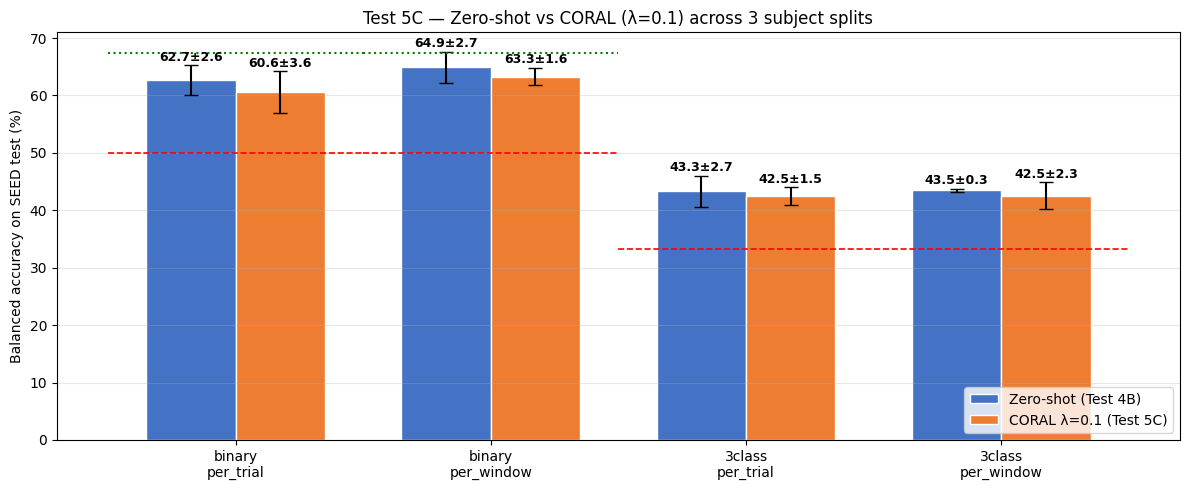

In [10]:
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'sans-serif', 'font.size': 10})
PLOTS_DIR = RESULTS_DIR / 'plots'
PLOTS_DIR.mkdir(parents=True, exist_ok=True)

fig, ax = plt.subplots(figsize=(12, 5))
configs = []
zero_means, zero_stds = [], []
coral_means, coral_stds = [], []
for mapping in ['binary', '3class']:
    for protocol in ['per_trial', 'per_window']:
        configs.append(f'{mapping}\n{protocol}')
        zm, zs = TEST4B_MEAN[(mapping, protocol)]
        zero_means.append(zm); zero_stds.append(zs)
        sub = DF_PER[(DF_PER['mapping']==mapping) & (DF_PER['protocol']==protocol)]
        coral_means.append(sub['test_bal'].mean())
        coral_stds.append(sub['test_bal'].std())

x = np.arange(len(configs)); w = 0.35
b1 = ax.bar(x - w/2, zero_means, w, yerr=zero_stds, label='Test 4B (SEED-val)',
            color='#4472C4', capsize=5, edgecolor='white')
b2 = ax.bar(x + w/2, coral_means, w, yerr=coral_stds, label='CORAL λ=0.1 (Test 5C)',
            color='#ED7D31', capsize=5, edgecolor='white')

for bar, val, std in zip(b1, zero_means, zero_stds):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.8, f'{val:.1f}±{std:.1f}',
            ha='center', fontsize=9, fontweight='bold')
for bar, val, std in zip(b2, coral_means, coral_stds):
    ax.text(bar.get_x() + bar.get_width()/2, val + std + 0.8, f'{val:.1f}±{std:.1f}',
            ha='center', fontsize=9, fontweight='bold')

# Chance lines
for i, cfg in enumerate(configs):
    ch = 50.0 if 'binary' in cfg else 33.3
    ax.hlines(ch, x[i]-0.5, x[i]+0.5, colors='red', linestyles='dashed', linewidth=1.2)

# Imtiaz & Khan reference for binary
for i, cfg in enumerate(configs):
    if 'binary' in cfg:
        ax.hlines(67.44, x[i]-0.5, x[i]+0.5, colors='green', linestyles=':', linewidth=1.5)

ax.set_xticks(x); ax.set_xticklabels(configs)
ax.set_ylabel('Balanced accuracy on SEED test (%)')
ax.set_title('Test 5C — Zero-shot vs CORAL (λ=0.1) across 3 subject splits')
ax.legend(loc='lower right'); ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(PLOTS_DIR / 'test5c_zero_vs_coral.png', dpi=140, bbox_inches='tight')
plt.show()

## 10. Interpretation

**Read Section 8's comparison table.** Two possible outcomes:

### Case 1: CORAL still helps on most configs
- If binary per_window and 3-class configs still show +2 pp or more from CORAL
- Report: "CORAL UDA (λ=0.1) improves cross-dataset transfer by X pp on average"
- Compare mean to Imtiaz & Khan 67.44%

### Case 2: CORAL improvement was single-split luck
- If CORAL mean is within ±1 pp of zero-shot mean across splits
- Report: "CORAL showed apparent improvement on one split but doesn't hold across splits"
- Honest negative finding — CORAL doesn't reliably help

**Either way — this is the finding.** Report both Test 4B and CORAL (Test 5C) means side by side.

**Ready for R7 final docx after this test finishes.**